In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [21]:
recommendations = pd.read_csv('Game Recommendations on Steam/recommendations.csv')
users = pd.read_csv('Game Recommendations on Steam/users.csv')
games = pd.read_csv('Game Recommendations on Steam/games.csv')

In [26]:
df = recommendations.merge(games, on="app_id", how="left")

In [17]:
recommendations.head()

,app_id,helpful,funny,date,is_recommended,hours,user_id,review_id
0,975370,0,0,2022-12-12,True,36.3,51580,0
1,304390,4,0,2017-02-17,False,11.5,2586,1
2,1085660,2,0,2019-11-17,True,336.5,253880,2
3,703080,0,0,2022-09-23,True,27.4,259432,3
4,526870,0,0,2021-01-10,True,7.9,23869,4


In [25]:
games.head(n=5)

,app_id,title,date_release,win,mac,linux,rating,positive_ratio,user_reviews,price_final,price_original,discount,steam_deck
0,13500,Prince of Persia: Warrior Within™,2008-11-21,True,False,False,Very Positive,84,2199,9.99,9.99,0.0,True
1,22364,BRINK: Agents of Change,2011-08-03,True,False,False,Positive,85,21,2.99,2.99,0.0,True
2,113020,Monaco: What's Yours Is Mine,2013-04-24,True,True,True,Very Positive,92,3722,14.99,14.99,0.0,True
3,226560,Escape Dead Island,2014-11-18,True,False,False,Mixed,61,873,14.99,14.99,0.0,True
4,249050,Dungeon of the ENDLESS™,2014-10-27,True,True,False,Very Positive,88,8784,11.99,11.99,0.0,True


In [ ]:
juegos_distintos = recommendations['app_id'].nunique()
print(f"Juegos distintos con recomendaciones: {juegos_distintos}")
print(f"Juegos totales: {games['app_id'].nunique()}")

Juegos distintos con recomendaciones: 37610
Juegos totales: 50872


In [14]:
# Promedio, mínimo y máximo de reviews por usuario
ratings_por_user = users.set_index("user_id")["reviews"]
reviews_por_user = recommendations.groupby("user_id").size()
print("Promedio de ratings por usuario:", ratings_por_user.mean())
print("Mínimo:", ratings_por_user.min())
print("Máximo:", ratings_por_user.max())


Promedio de ratings por usuario: 2.8767377246459964
Mínimo: 0
Máximo: 6045


In [15]:
reviews_por_user.describe()

count    1.378106e+07
mean     2.986330e+00
std      8.118011e+00
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      3.000000e+00
max      6.045000e+03
dtype: float64

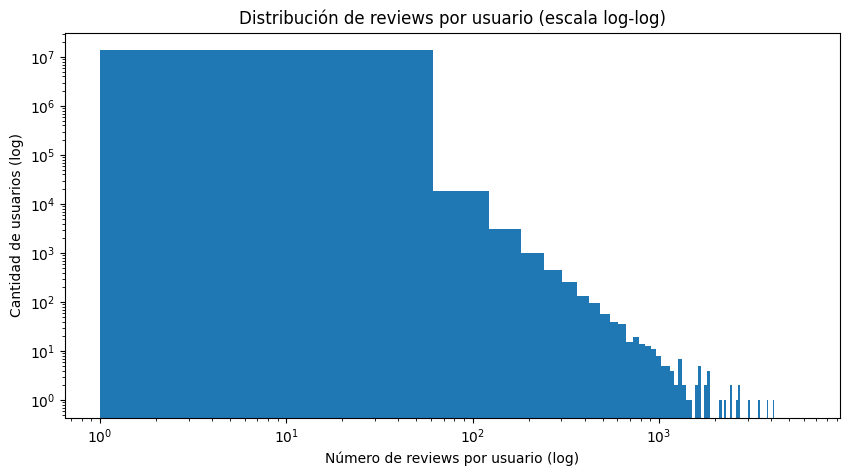

In [16]:
plt.figure(figsize=(10,5))
plt.hist(reviews_por_user, bins=100)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Número de reviews por usuario (log)")
plt.ylabel("Cantidad de usuarios (log)")
plt.title("Distribución de reviews por usuario (escala log-log)")
plt.show()


In [6]:
reviews_por_item = recommendations.groupby("app_id").size()
promedio = reviews_por_item.mean()
minimo = reviews_por_item.min()
maximo = reviews_por_item.max()

print("Promedio de reviews por item:", promedio)
print("Mínimo:", minimo)
print("Máximo:", maximo)

Promedio de reviews por item: 1094.2513693166711
Mínimo: 1
Máximo: 319492


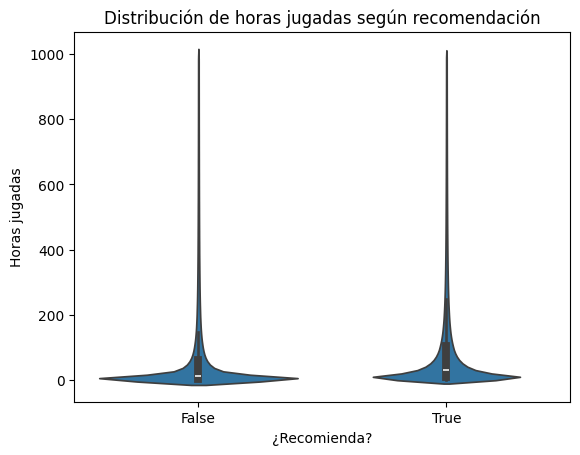

In [19]:
sns.violinplot(data=recommendations, x="is_recommended", y="hours")
plt.title("Distribución de horas jugadas según recomendación")
plt.xlabel("¿Recomienda?")
plt.ylabel("Horas jugadas")
plt.show()


Los usuarios que recomiendan tienden a jugar un poco más horas que quienes no recomiendan. No es una diferencia gigante, pero sí existe.

In [ ]:
# Porcentaje de recomendaciones positivas por juego
recs_por_juego = df.groupby("app_id")["is_recommended"].mean()


count    37610.000000
mean         0.767441
std          0.194332
min          0.000000
25%          0.666667
50%          0.811765
75%          0.915389
max          1.000000
Name: is_recommended, dtype: float64

<Axes: xlabel='price_final', ylabel='rec_rate'>

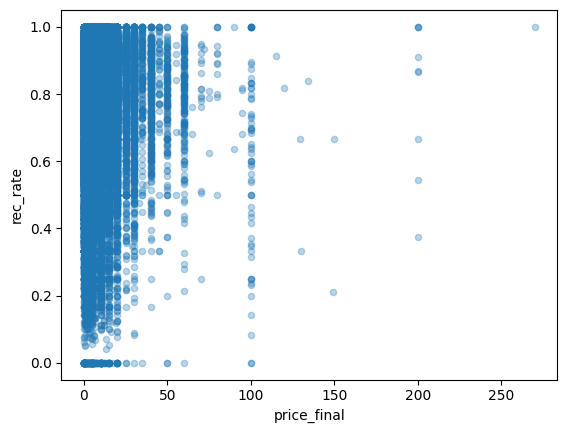

In [ ]:
# Relación: precio_final vs. % recomendaciones
precio_rec = df.groupby("app_id")["is_recommended"].mean().to_frame("rec_rate")
precio_rec = precio_rec.merge(games[["app_id","price_final"]], on="app_id")

precio_rec.plot.scatter(x="price_final", y="rec_rate", alpha=0.3)


<Axes: xlabel='positive_ratio', ylabel='rec_rate'>

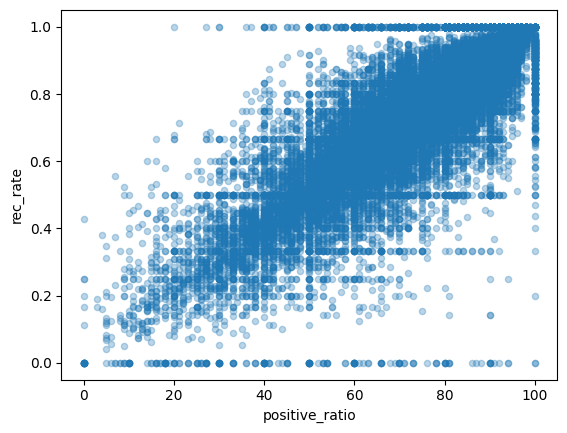

In [ ]:
# Relación: positive_ratio vs % recomendaciones
rel = df.groupby("app_id")["is_recommended"].mean().to_frame("rec_rate")
rel = rel.merge(games[["app_id","positive_ratio"]], on="app_id")

rel.plot.scatter(x="positive_ratio", y="rec_rate", alpha=0.3)


<Axes: xlabel='avg_hours', ylabel='rec_rate'>

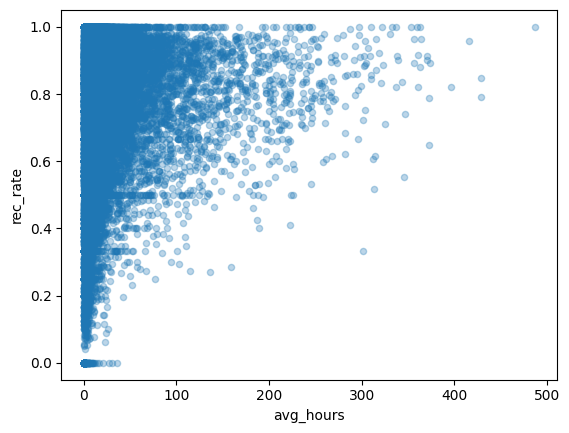

In [ ]:
# Horas jugadas vs recomendación (por juego) 
hours = df.groupby("app_id")["hours"].mean().to_frame("avg_hours")
hours = hours.merge(df.groupby("app_id")["is_recommended"].mean().to_frame("rec_rate"), on="app_id")

hours.plot.scatter(x="avg_hours", y="rec_rate", alpha=0.3)


<Axes: xlabel='year', ylabel='rec_rate'>

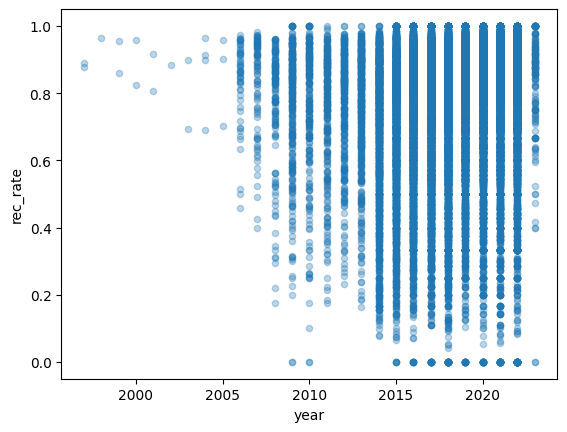

In [ ]:
# Años de lanzamiento vs recomendaciones
games["year"] = pd.to_datetime(games["date_release"]).dt.year

rel = df.groupby("app_id")["is_recommended"].mean().to_frame("rec_rate")
rel = rel.merge(games[["app_id","year"]], on="app_id")

rel.plot.scatter(x="year", y="rec_rate", alpha=0.3)


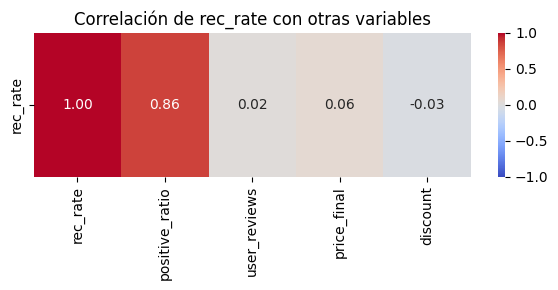

In [37]:
# Matriz de correlación entre variables del juego y % recomendación
combined = df.groupby("app_id")["is_recommended"].mean().to_frame("rec_rate")
combined = combined.merge(games.set_index("app_id"), on="app_id")

corr = combined[["rec_rate","positive_ratio","user_reviews","price_final","discount"]].corr()

plt.figure(figsize=(6, 3))
sns.heatmap(
    corr[["rec_rate"]].T,  # solo rec_rate como columna
    annot=True,
    fmt=".2f",
    vmin=-1, vmax=1,
    cmap="coolwarm",
    cbar=True
)
plt.title("Correlación de rec_rate con otras variables")
plt.tight_layout()
plt.show()


In [40]:
games["platform_count"] = games[["win", "mac", "linux", "steam_deck"]].sum(axis=1)
recs = df.groupby("app_id")["is_recommended"].mean().to_frame("rec_rate")
combined = recs.merge(games[["platform_count"]], left_index=True, right_index=True)

In [41]:
combined.groupby("platform_count")["rec_rate"].mean()

platform_count
1    0.766409
2    0.762594
3    0.799620
4    0.774524
Name: rec_rate, dtype: float64

In [46]:
combined["platform_count"].value_counts()

platform_count
2    618
4    153
3    127
1     10
Name: count, dtype: int64